TASK 01
Compute derivatives by hand, verify with sympy

By hand, using the power rule, find the derivative of each: f(x)=xn, g(x)=3x²+2x-7, h(x)=1/x (rewrite as
xn¹).
• For each, confirm your answer with sympy.diff.

In [1]:
import sympy as sp
x = sp.symbols('x')
n = sp.symbols("n")


f = x**n
g = 3*x**2 + 2*x - 7
h = 1/x

print("f'(x) =", sp.diff(f, x))        #n*x**n-1
print("g'(x) =", sp.diff(g, x))        #6*x + 2
print("h'(x) =", sp.diff(h, x))        #-1/x**2


n_value = 4 


f'(x) = n*x**n/x
g'(x) = 6*x + 2
h'(x) = -1/x**2


Evaluate each derivative at x=2 — both your hand value and sympy's.

In [2]:
sym_f = sp.diff(f, x).subs(x, 2)
sym_g = sp.diff(g, x).subs(x, 2)
sym_h = sp.diff(h, x).subs(x, 2)

print(sym_f)
print(sym_g)
print(sym_h)

2**n*n/2
14
-1/4


Now write a numerical_derivative(f, x) function using the tiny-step method, and confirm it agrees with
the exact derivatives at x=2.

In [ ]:
def numerical_derivative(func, x_value, h=1e-5):
    return (func(x_value + h) - func(x_value - h)) / (2 * h)


def numerical_derivative(func, x_value, h=1e-5):
    return (func(x_value + h) - func(x_value - h)) / (2 * h)


# Python functions
def f_num(x):
    return x**n

def g_num(x):
    return 3*x**2 + 2*x - 7

def h_num(x):
    return 1/x

#Numeric Derivatives


print(f"f'(2) ≈ {numerical_derivative(f_num, 2)}")
print(f"g'(2) ≈ {numerical_derivative(g_num, 2)}")
print(f"h'(2) ≈ {numerical_derivative(h_num, 2)}")


f'(2) ≈ 32.000000001009
g'(2) ≈ 14.000000000002897
h'(2) ≈ -0.2500000000099645


In [4]:
derivative = sp.diff(x**n, x)
print("General derivative:", derivative)

solution = sp.solve(sp.Eq(derivative.subs(n, n_value), 0), x)
print(f"For n = {n_value}, derivative is zero at:", solution)

if solution:
    print("\nInterpretation:")
    if n_value % 2 == 0:
        print("The function has a minimum point at x = 0.")
    else:
        print("The function has a stationary inflection point at x = 0.")

General derivative: n*x**n/x
For n = 4, derivative is zero at: [0]

Interpretation:
The function has a minimum point at x = 0.


TASK 02
Plot a function against its derivative

Pick a function with an interesting shape — a cubic like f(x)=x³-3x works well (it has two flat spots).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')

f = x**3 - 3*x
df = sp.diff(f, x)

In [6]:
critical_points = sp.solve(df, x)
print(critical_points)

[-1, 1]


Plot f(x) and its derivative f'(x) on two panels, one above the other, sharing the x-axis.

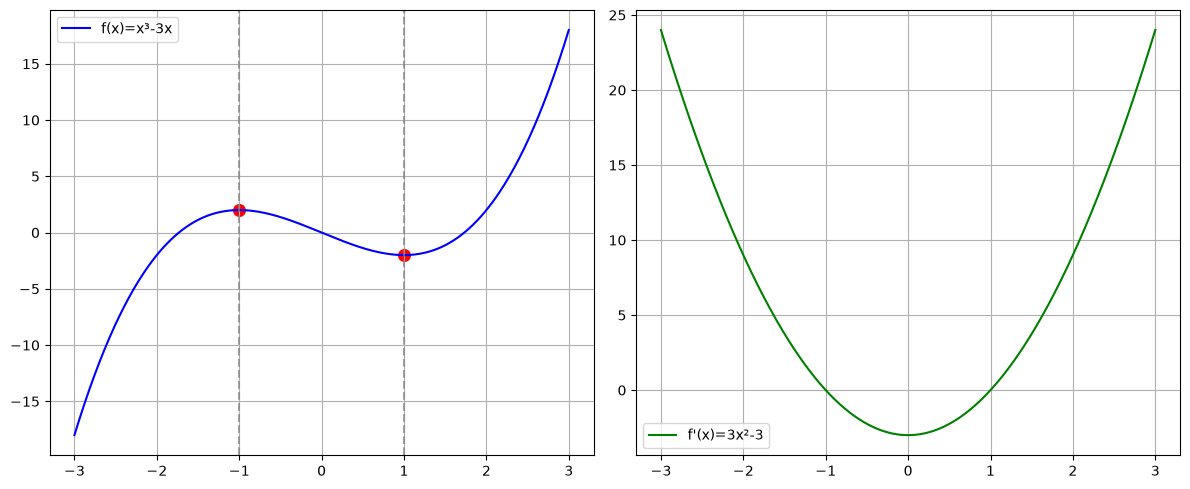

In [7]:
x_vals = np.linspace(-3, 3, 400)
f_num = sp.lambdify(x, f, "numpy")
df_num = sp.lambdify(x, df, "numpy")

y_vals = f_num(x_vals)
dy_vals = df_num(x_vals)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Left plot: Original Function
ax[0].plot(x_vals, y_vals, color="blue", label="f(x)=x³-3x")

# Right plot: Derivative
ax[1].plot(x_vals, dy_vals, color="green", label="f'(x)=3x²-3")
for cp in critical_points:
    cp = float(cp)
    ax[0].scatter(cp, f_num(cp), color="red", s=70)
    ax[0].axvline(cp, color="gray", linestyle="--", alpha=0.7)

ax[0].grid(True)
ax[1].grid(True)
ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()


#You can identify peaks and valleys from the derivative plot because they occur where the derivative crosses zero and changes sign: positive to negative indicates a peak, while negative to positive indicates a valley.

TASK 03
Partial derivatives and the gradient


Take f(x,y) = x² + 2y² + xy. By hand, find both partial derivatives, treating the other variable as a
constant.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, y = sp.symbols("x y")
f = x**2 + 2*y**2 + x*y
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)


print("f'(x)",df_dx)
print("f'(y)",df_dy)

f'(x) 2*x + y
f'(y) x + 4*y


In [9]:
def gradient(px, py):
    return np.array([2*px + py, 4*py + px])

def func(px, py):
    return px**2 + 2*py**2 + px*py

In [10]:
points = [
    (1, 1),
    (-1, 2),
    (2, -1)
]

step = 0.1

for px, py in points:

    g = gradient(px, py)

    direction = g / np.linalg.norm(g)

    original = func(px, py)

    uphill = func(
        px + step * direction[0],
        py + step * direction[1]
    )

    downhill = func(
        px - step * direction[0],
        py - step * direction[1]
    )

    print(f"\nPoint ({px}, {py})")
    print("Gradient:", g)
    print("Original:", original)
    print("Step uphill:", uphill)
    print("Step downhill:", downhill)


Point (1, 1)
Gradient: [3 5]
Original: 4
Step uphill: 4.604859895366882
Step downhill: 3.4386695163978227

Point (-1, 2)
Gradient: [0 7]
Original: 7
Step uphill: 7.720000000000001
Step downhill: 6.3199999999999985

Point (2, -1)
Gradient: [ 3 -2]
Original: 4
Step uphill: 4.369016666007937
Step downhill: 3.647906410915139


Draw the function as a contour plot and overlay gradient arrows on a grid, as the notebook did. Confirm they all
point away from the minimum.

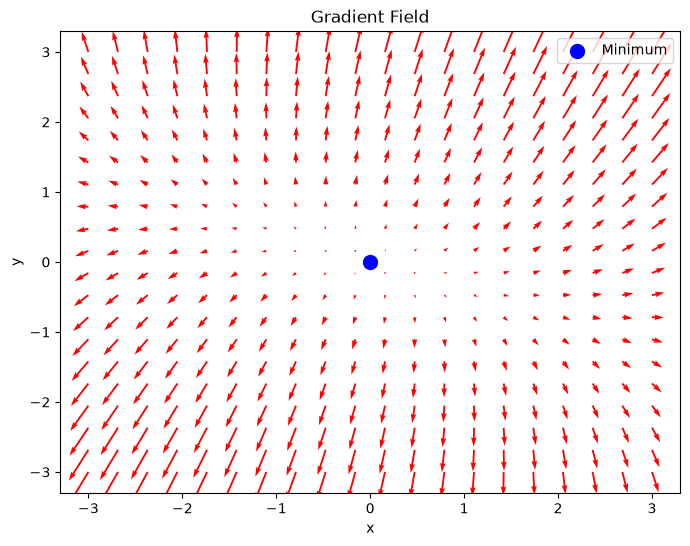

In [16]:
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)

X, Y = np.meshgrid(x, y)

Z = func(X, Y)

GX = 2*X + Y
GY = X + 4*Y

plt.figure(figsize=(8, 6))

# plt.contour(X, Y, Z, levels=20)

plt.quiver(X, Y, GX, GY, color="red")

plt.scatter(0, 0, color="blue", s=100, label="Minimum")

plt.title("Gradient Field")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

TASK 04
The chain rule, by hand and in code


Take the composed function f(x) = (3x + 1)n. Identify the outer function and the inner function.
• By hand, apply the chain rule: outer derivative times inner derivative.
• Verify with sympy.
• Verify again numerically with your tiny-step method at a couple of x values. All three should agree.
• Now do a three-layer chain: f(x) = sin((2x+1)²). Apply the chain rule twice — work from the outside in.
Verify with sympy.
• Write two sentences explaining, in your own words, why the chain rule multiplies the derivatives.

In [12]:
import numpy as np
import sympy as sp

x = sp.Symbol("x")

# f(x) = (3x + 1)^n

n = 4

f = (3*x + 1)**n

manual = n * (3*x + 1)**(n-1) * 3
sympy_derivative = sp.diff(f, x)

print("Function:")
print(f)

print("\nManual derivative:")
print(manual)

print("\nSymPy derivative:")
print(sympy_derivative)

f_num = sp.lambdify(x, f, "numpy")
d_num = sp.lambdify(x, manual, "numpy")


def numerical_derivative(func, x_value, h=1e-5):
    return (func(x_value + h) - func(x_value - h)) / (2 * h)


points = [0, 2]

print("\nVerification")

for p in points:
    print(f"\nx = {p}")
    print("Manual :", d_num(p))
    print("SymPy  :", float(sympy_derivative.subs(x, p)))
    print("Numeric:", numerical_derivative(f_num, p))


# f(x) = sin((2x+1)^2)-

g = sp.sin((2*x + 1)**2)

manual2 = sp.cos((2*x + 1)**2) * (2*(2*x + 1)) * 2
sympy2 = sp.diff(g, x)


print("\n\nSecond Function:",g)

print("\nManual derivative:",manual2)

print("\nSymPy derivative:", sympy2)

g_num = sp.lambdify(x, g, "numpy")
dg_num = sp.lambdify(x, manual2, "numpy")

print("\nVerification")

for p in points:
    print(f"\nx = {p}")
    print("Manual :", dg_num(p))
    print("SymPy  :", float(sympy2.subs(x, p)))
    print("Numeric:", numerical_derivative(g_num, p))

Function:
(3*x + 1)**4

Manual derivative:
12*(3*x + 1)**3

SymPy derivative:
12*(3*x + 1)**3

Verification

x = 0
Manual : 12
SymPy  : 12.0
Numeric: 12.000000010786714

x = 2
Manual : 4116
SymPy  : 4116.0
Numeric: 4116.000000180975


Second Function: sin((2*x + 1)**2)

Manual derivative: 2*(4*x + 2)*cos((2*x + 1)**2)

SymPy derivative: (8*x + 4)*cos((2*x + 1)**2)

Verification

x = 0
Manual : 2.161209223472559
SymPy  : 2.161209223472559
Numeric: 2.1612092215461676

x = 2
Manual : 19.82405623726947
SymPy  : 19.82405623726947
Numeric: 19.824056106297615


TASK 05
Backpropagation by hand

• Build a tiny two-stage computation: a = w*x, then loss = (a - target)². Use x=2, w=1.5, target=10.

• Do the forward pass: compute a, then the loss.

• Do the backward pass by hand: find d(loss)/d(a), then d(a)/d(w), then chain them for d(loss)/d(w).

• Verify d(loss)/d(w) numerically by nudging w and measuring the loss change.

• Interpret the sign: should w increase or decrease to reduce the loss? Take one gradient-descent step and
confirm the loss actually drops.

In [13]:
import numpy as np

x, w, target = 2, 1.5, 10

a = w * x
loss = (a - target) ** 2

print(a, loss)

dL_da = 2 * (a - target)
da_dw = x
dL_dw = dL_da * da_dw

print(dL_da, da_dw, dL_dw)


def compute_loss(w):
    return (w * x - target) ** 2


def numerical_gradient(w, h=1e-5):
    return (compute_loss(w + h) - compute_loss(w - h)) / (2 * h)


print("Analytical:", dL_dw)
print("Numerical :", numerical_gradient(w))

lr = 0.1

new_w = w - lr * dL_dw

print("Old loss:", compute_loss(w))
print("New loss:", compute_loss(new_w))

if dL_dw < 0:
    print("Increase w")
else:
    print("Decrease w")

3.0 49.0
-14.0 2 -28.0
Analytical: -28.0
Numerical : -28.000000000361066
Old loss: 49.0
New loss: 1.959999999999996
Increase w


TASK 06
Code gradient descent from scratch — then break it

• Write gradient_descent(gradient_fn, start, learning_rate, steps) that returns the full history
of positions.

• Use it to minimise f(x) = (x-5)² starting from x=0. Confirm it reaches x=5.

• Plot the function with each step marked on it, as the notebook did. Watch the steps shrink near the minimum.

• Now the important part — break it. Run it with learning rates 0.01, 0.1, 0.5, 1.0, and 1.05. For each, report
where it ends up.

• Find, by experiment, the learning rate above which it diverges (overshoots and blows up) instead of converging.
What is special about that threshold for this function?

• Minimise a harder function with two minima, like f(x)=xn-3x²+x. Start from different points and show it can
end up in different minima depending on where it starts.

• Write two sentences: what did the too-large learning rate do, and why does the starting point matter for the
two-minima function?

Final x: 4.993810299803573


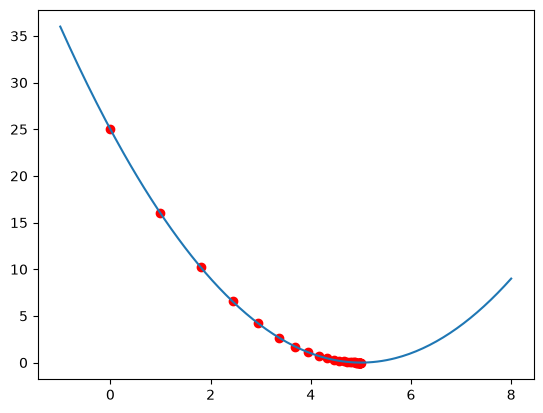

0.01 -> 2.2725784030878136
0.1 -> 4.993810299803573
0.5 -> 5.0
1.0 -> 0.0
1.05 -> -82.2470113444323
Diverges near: 1.260000000000001
Start: -2 End: -1.300839565941577
Start: -1 End: -1.300839565941577
Start: 0 End: -1.300839565941577
Start: 1 End: 1.1309011226299857
Start: 2 End: 1.1309011226299857


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(grad, start, lr, steps):
    x = start
    history = [x]
    for _ in range(steps):
        x -= lr * grad(x)
        history.append(x)
    return history


# f(x) = (x-5)^2
f = lambda x: (x - 5) ** 2
grad = lambda x: 2 * (x - 5)

history = gradient_descent(grad, 0, 0.1, 30)

print("Final x:", history[-1])

x = np.linspace(-1, 8, 200)

plt.plot(x, f(x))
plt.scatter(history, [f(i) for i in history], color="red")
plt.show()


# Different learning rates
for lr in [0.01, 0.1, 0.5, 1.0, 1.05]:
    h = gradient_descent(grad, 0, lr, 30)
    print(lr, "->", h[-1])


# Find divergence
lr = 0.1
while lr <= 2:
    h = gradient_descent(grad, 0, lr, 30)
    if abs(h[-1]) > 1e6:
        print("Diverges near:", lr)
        break
    lr += 0.01


# Two-minima function
f2 = lambda x: x**4 - 3*x**2 + x
grad2 = lambda x: 4*x**3 - 6*x + 1

for start in [-2, -1, 0, 1, 2]:
    h = gradient_descent(grad2, start, 0.05, 100)
    print("Start:", start, "End:", h[-1])